# Air Quality Veri Seti

# 0.Kütüphanelerin Yüklenmesi

In [27]:
# Kütüphanelerin Yüklenmesi ve Kurulum
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

%matplotlib inline
sns.set(style="whitegrid")

## 0. Verinin Yüklenmesi

In [ ]:
df_air = pd.read_csv('Air Quality.csv', sep=',') 

# Satır sonundaki çift virgüllerden (,,) kaynaklanan isimsiz boş hayalet kolonları uçuruyoruz.
df_air = df_air.loc[:, ~df_air.columns.str.contains('^Unnamed')]

# Tamamen boş satırları temizleme
df_air = df_air.dropna(how='all')

#Tarih birleştirmedeki saat formatı '%H:%M:%S' olarak güncellendi.
df_air['Datetime'] = pd.to_datetime(df_air['Date'] + ' ' + df_air['Time'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
df_air = df_air.dropna(subset=['Datetime'])
df_air.set_index('Datetime', inplace=True)

# Kronolojik sıralama
df_air.sort_index(inplace=True)

print("Zaman Serisi Boyutu ---")
print(df_air.shape)
df_air.info()

Zaman Serisi Boyutu ---
(9357, 15)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


## 1.1 EDA - Veri Kümesi Açıklaması

Bu veri seti, İtalya'da hava kirliliğinin yoğun olduğu bir bölgeye yerleştirilmiş saha laboratuvarındaki kimyasal sensörlerin saatlik ölçümlerini içermektedir. Veri setinde iki ana tür ölçüm bulunmaktadır:
1. **(GT) Uzantılı Değişkenler:** Resmi referans analiz cihazları tarafından ölçülen kesin, gerçek konsantrasyon değerleridir (Ground Truth).
2. **PT08 Başlıklı Değişkenler:** Sahaya yerleştirilen daha ekonomik metal-oksit yarı iletken kimyasal sensörlerin verdiği elektriksel tepki (sinyal) değerleridir.

### Değişkenlerin Detaylı Karakteristiği ve Teknik Açıklamaları:

1. **Date:** Ölçümün yapıldığı gün, ay ve yıl bilgisi (GG/AA/YYYY). Zaman serisi indeksi oluşturulurken temel bileşen olarak kullanılmıştır.
2. **Time:** Ölçümün yapıldığı saat bilgisi (SS:DD:SS). Veri seti saatlik frekansta (`hourly`) toplanmıştır.
3. **CO(GT):** Gerçek saatlik ortalama Karbonmonoksit (CO) konsantrasyonu. Ölçüm birimi $mg/m^3$'tür. **Projemizin hedef (target) değişkenidir.**
4. **PT08.S1(CO):** CO (Karbonmonoksit) gazını hedefleyen PT08.S1 kalay-oksit (SnO2) kimyasal sensörünün saatlik ortalama tepki sinyali.
5. **NMHC(GT):** Gerçek saatlik ortalama Metan Dışı Hidrokarbon (Non-Methane Hydrocarbons) konsantrasyonu. Ölçüm birimi $\mu g/m^3$'tür. *(NOT: Bu değişken, veri toplama sürecinin ortasında ölçümü durdurulduğu ve test setinde tamamen boş geldiği için veri sızıntısını ve model çökmesini önlemek adına veri setinden elenmiştir).*
6. **C6H6(GT):** Gerçek saatlik ortalama Benzen ($C_6H_6$) konsantrasyonu. Ölçüm birimi $\mu g/m^3$'tür. Özellikle endüstriyel kirlilik ve yakıt buharlaşmasının önemli bir göstergesidir.
7. **PT08.S2(NMHC):** Metan Dışı Hidrokarbonları (NMHC) hedefleyen PT08.S2 titanyum-oksit ($TiO_2$) sensörünün saatlik ortalama tepki sinyali.
8. **NOx(GT):** Gerçek saatlik ortalama Azot Oksitleri ($NO_x$) konsantrasyonu. Ölçüm birimi ppb (milyarda bir parçacık) cinsindendir. Genellikle dizel araç egzoz emisyonlarının doğrudan göstergesidir.
9. **PT08.S3(NOx):** Azot Oksitlerini ($NO_x$) hedefleyen PT08.S3 tungsten-oksit ($WO_3$) sensörünün saatlik ortalama tepki sinyali.
10. **NO2(GT):** Gerçek saatlik ortalama Azot Dioksit ($NO_2$) konsantrasyonu. Ölçüm birimi $\mu g/m^3$'tür. Solunum yolu sağlığını doğrudan etkileyen kritik bir kirleticidir.
11. **PT08.S4(NO2):** Azot Dioksit ($NO_2$) gazını hedefleyen PT08.S4 tungsten-oksit ($WO_3$) sensörünün saatlik ortalama tepki sinyali.
12. **PT08.S5(O3):** Ozon ($O_3$) gazını hedefleyen PT08.S5 indiyum-oksit ($In_2O_3$) sensörünün saatlik ortalama tepki sinyali.
13. **T (Temperature):** Ölçüm anındaki hava sıcaklığı (°C). Gazların havada dağılımını ve sensörlerin kimyasal tepkime hızını doğrudan etkileyen bir dış faktördür.
14. **RH (Relative Humidity):** Ölçüm anındaki Bağıl Nem yüzdesi (%). Havadaki nem miktarı, kimyasal sensörlerin yüzeyindeki iletkenliği değiştirdiği için model için kritik bir düzeltme faktörüdür.
15. **AH (Absolute Humidity):** Ölçüm anındaki Mutlak Nem miktarı. Sıcaklıktan bağımsız olarak havadaki gerçek su buharı yoğunluğunu temsil eder.

# 1.2 EDA - İSTATIKSEL ÖZET ve 1.3 EDA - VERİ GÖRSELLEŞTİRME

--- 1. HEDEF DEĞİŞKEN İSTATİSTİKSEL ÖZETİ ---
count    7674.000000
mean        2.152750
std         1.453252
min         0.100000
25%         1.100000
50%         1.800000
75%         2.900000
max        11.900000
Name: CO(GT), dtype: float64


C:\Users\mrsci\AppData\Local\Temp\ipykernel_12604\1747434289.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hour', y=target_col, data=df_eda, palette='viridis', ax=axes[1, 0])
C:\Users\mrsci\AppData\Local\Temp\ipykernel_12604\1747434289.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y=target_col, data=df_eda, palette='coolwarm', ax=axes[1, 1])


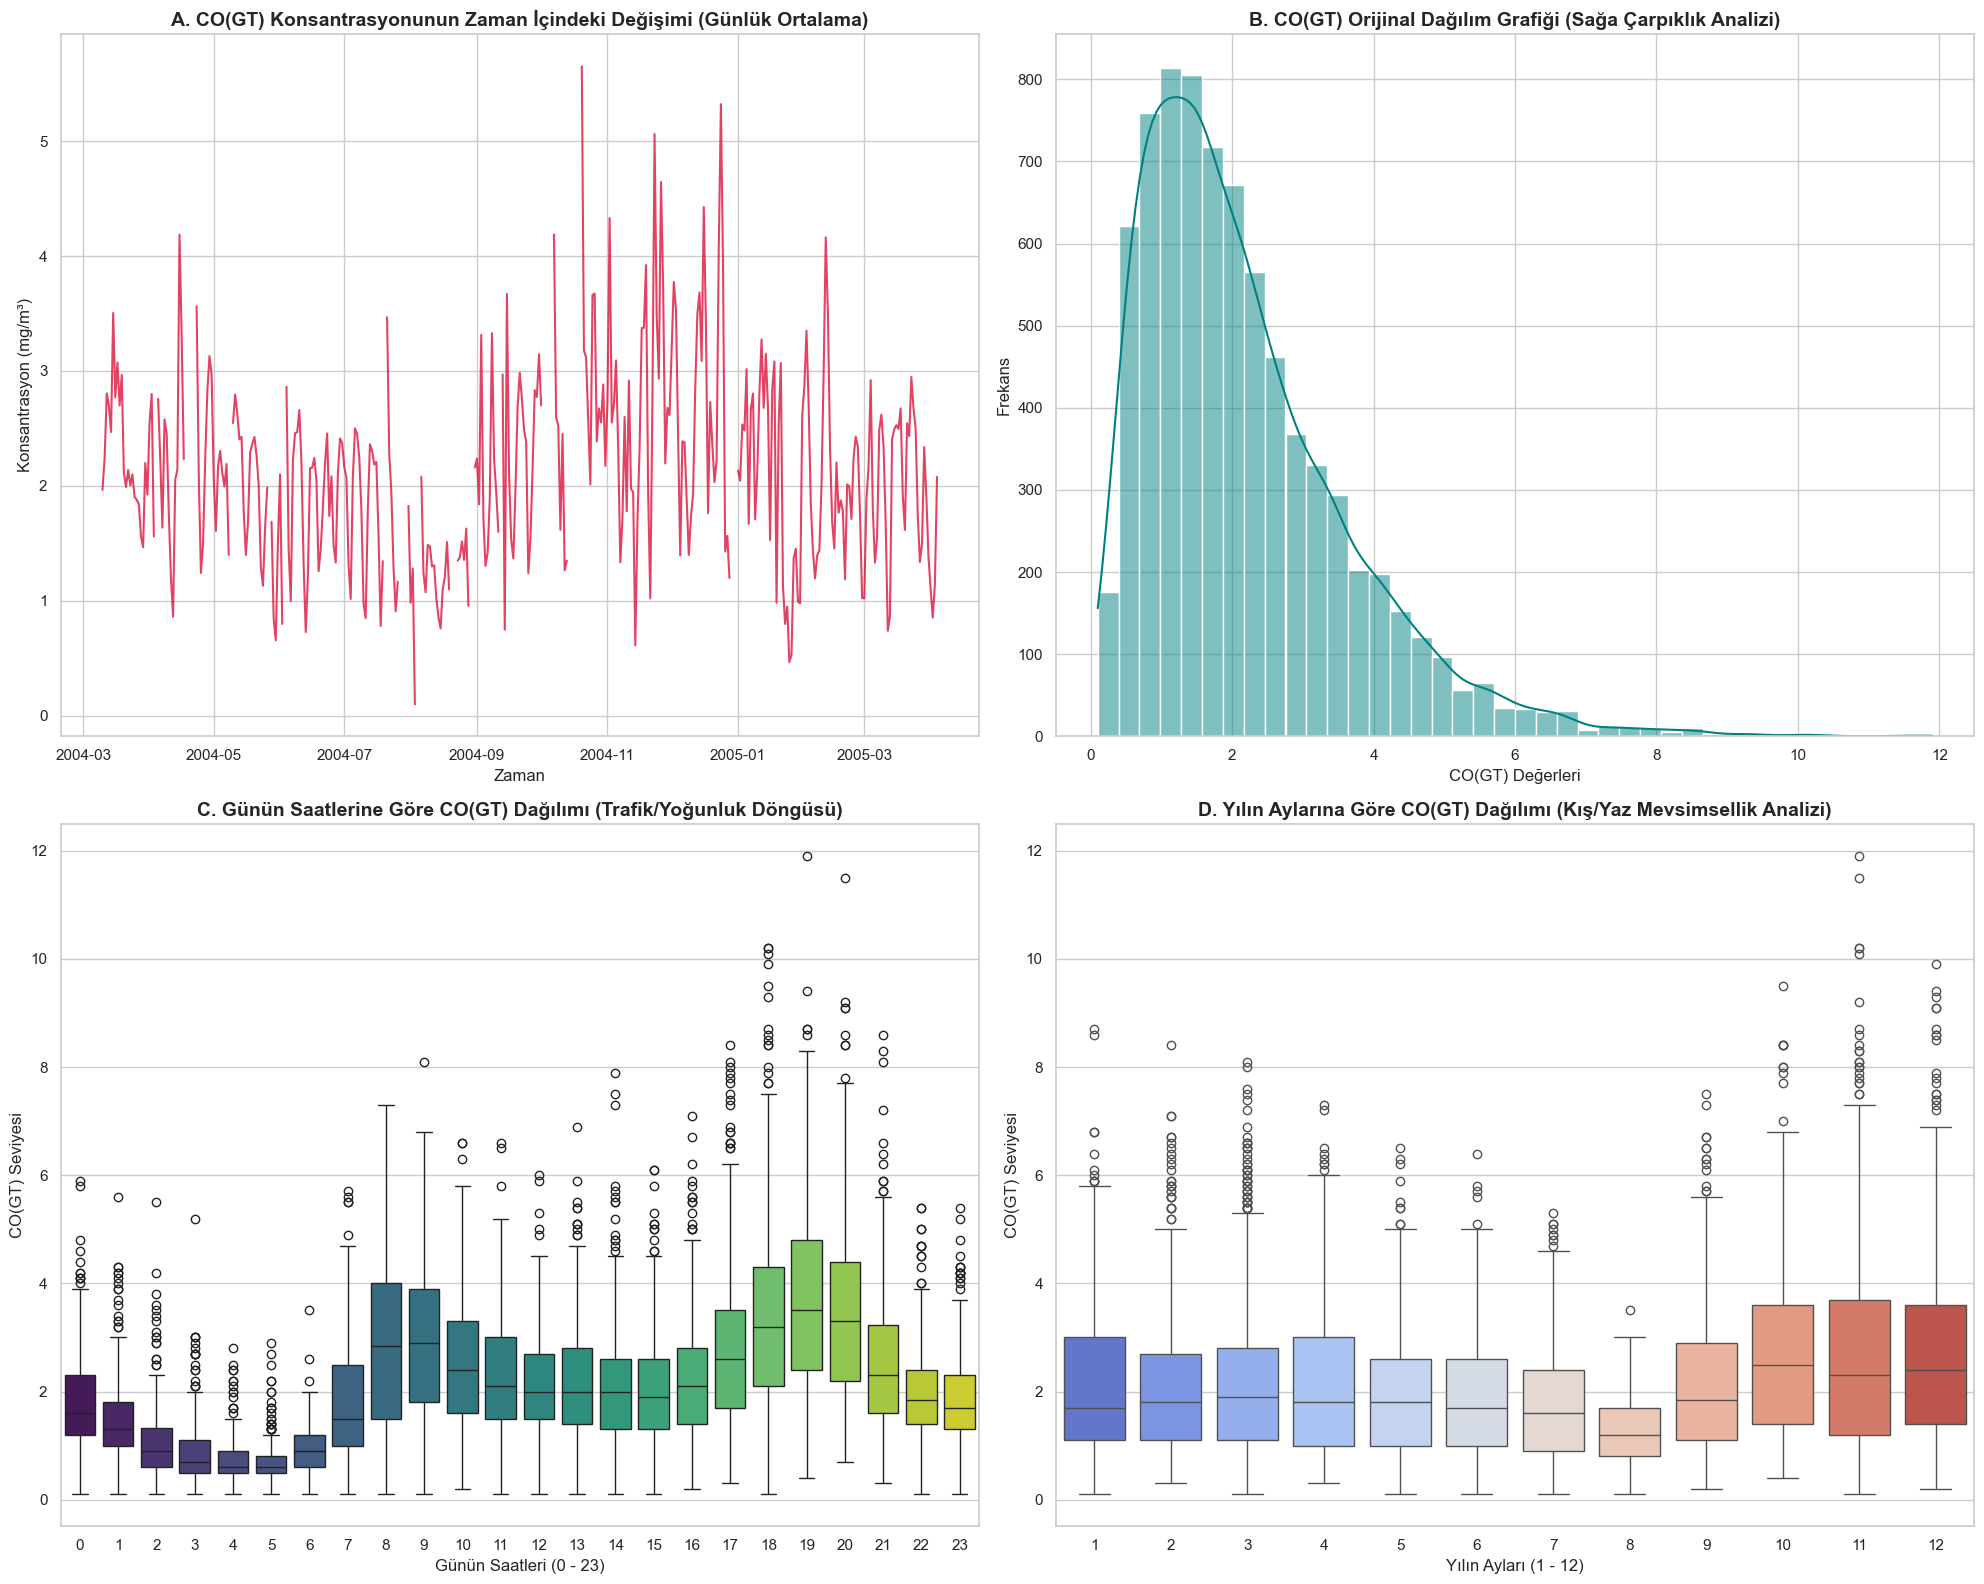

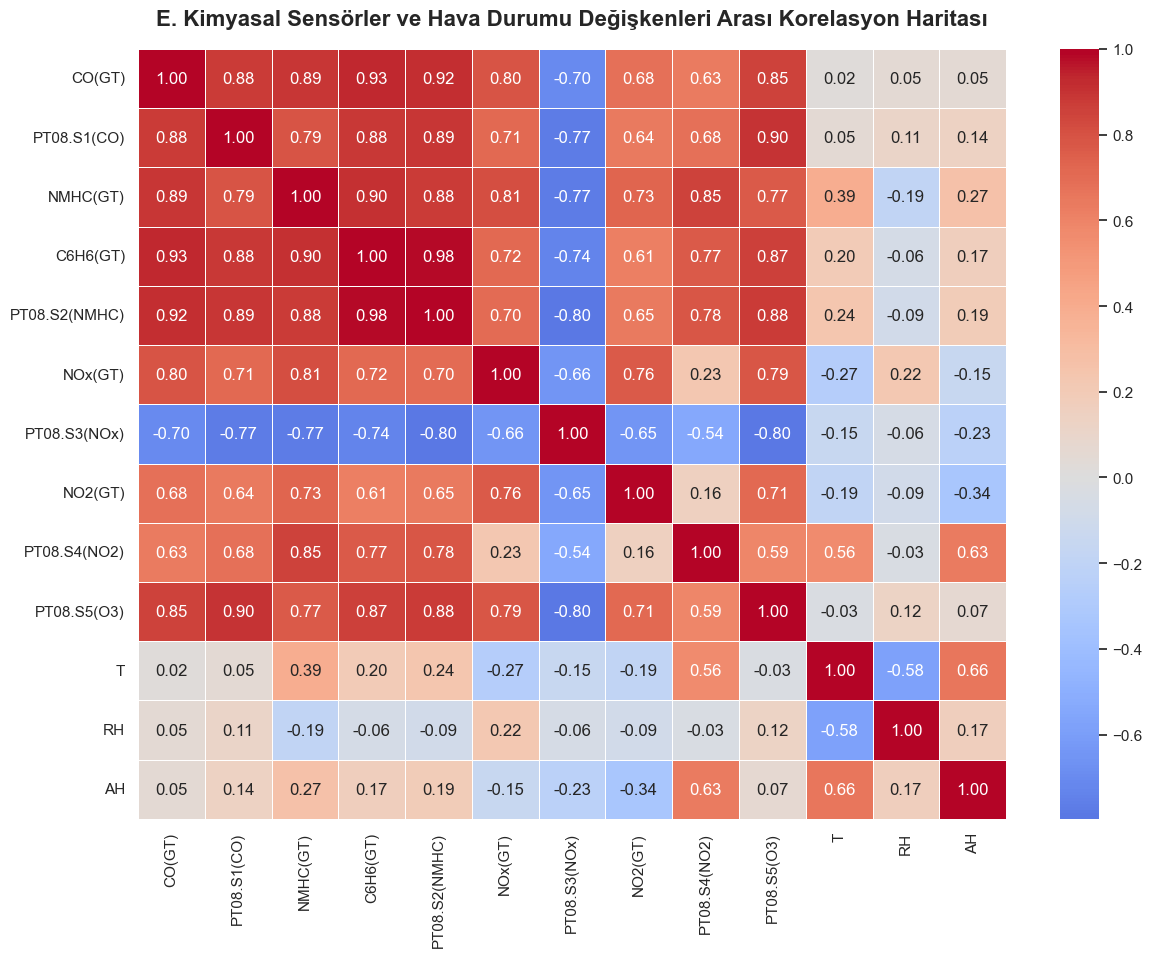

In [29]:
# Görselleştirmelerin -200 hatasından dolayı bozulmaması için geçici bir temiz kopya oluşturuyoruz
df_eda = df_air.replace(-200, np.nan)
target_col = 'CO(GT)'

print("--- 1. HEDEF DEĞİŞKEN İSTATİSTİKSEL ÖZETİ ---")
print(df_eda[target_col].describe())

# --- GRAFİK MATRİSİ BAŞLANGICI ---
# 2 satır, 2 sütunluk dev bir grafik alanı kuruyoruz
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# GRAFİK A: Zaman Serisi Çizgi Grafiği (Genel Trend ve Makro Döngüler)
axes[0, 0].plot(df_eda[target_col].resample('D').mean(), color='crimson', alpha=0.8, linewidth=1.5)
axes[0, 0].set_title('A. CO(GT) Konsantrasyonunun Zaman İçindeki Değişimi (Günlük Ortalama)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Zaman')
axes[0, 0].set_ylabel('Konsantrasyon (mg/m³)')

# GRAFİK B: Hedef Değişken Dağılımı (Çarpıklık ve Yoğunluk Analizi)
sns.histplot(df_eda[target_col], kde=True, color='teal', bins=40, ax=axes[0, 1])
axes[0, 1].set_title('B. CO(GT) Orijinal Dağılım Grafiği (Sağa Çarpıklık Analizi)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('CO(GT) Değerleri')
axes[0, 1].set_ylabel('Frekans')

# GRAFİK C: Saatlik Boxplot (Gün İçi Periyodiklik / Diurnal Patterns)
# Verinin saat indeksini çıkarıp boxplot çizdiriyoruz (Örn: Sabah ve akşam iş çıkışı saatlerindeki yoğunluk)
df_eda['Hour'] = df_eda.index.hour
sns.boxplot(x='Hour', y=target_col, data=df_eda, palette='viridis', ax=axes[1, 0])
axes[1, 0].set_title('C. Günün Saatlerine Göre CO(GT) Dağılımı (Trafik/Yoğunluk Döngüsü)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Günün Saatleri (0 - 23)')
axes[1, 0].set_ylabel('CO(GT) Seviyesi')

# GRAFİK D: Aylık Boxplot (Mevsimsel Değişim / Seasonal Patterns)
# Yılın aylarına göre ısınma emisyonlarını yakalamak için (Örn: Kış aylarındaki artış)
df_eda['Month'] = df_eda.index.month
sns.boxplot(x='Month', y=target_col, data=df_eda, palette='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('D. Yılın Aylarına Göre CO(GT) Dağılımı (Kış/Yaz Mevsimsellik Analizi)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Yılın Ayları (1 - 12)')
axes[1, 1].set_ylabel('CO(GT) Seviyesi')

plt.tight_layout()
plt.show()


# --- GRAFİK E: KORELASYON ISI HARİTASI (Korelasyon Matrisi) ---
# Gazların ve sensörlerin birbirleriyle olan ilişkisini ölçüyoruz
plt.figure(figsize=(14, 10))
# Sadece sayısal olan ve zaman özellikleri dışındaki sütunları alıyoruz
numeric_cols = [col for col in df_eda.columns if col not in ['Hour', 'Month'] and df_eda[col].dtype in [np.float64, np.int64]]
corr_matrix = df_eda[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
plt.title('E. Kimyasal Sensörler ve Hava Durumu Değişkenleri Arası Korelasyon Haritası', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# 2.1 VERİ TEMİZLEME - EKSİK VE GEÇERSİZ VERİLERİN TESPİTİ VE TEMİZLENMESİ

In [30]:
# Air Quality setinde gerçek eksik değerler -200 olarak kodlanmıştır. Bunları NaN yapıyoruz.
df_air = df_air.replace(-200, np.nan)

print("Sütunlardaki Gerçek Eksik Değer Sayıları:")
print(df_air.isnull().sum())

# Zaman serisinde fillna(median) yapılmaz. 
# Zamansal süreklilik için forward fill (biri önceki saatin değerini taşıma) veya linear interpolation yapılır.
# Veri sızıntısını önlemek için bu doldurma mantığını Preprocessing adımında, bölme sonrasında gerçekleştireceğiz.

Sütunlardaki Gerçek Eksik Değer Sayıları:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


# 2.2 VERİ TEMİZLEME - AYKIRI DEĞER TESPİTİ VE TUTARSIZLIKLARI GİDERMEK

In [31]:
# 1. IQR Sınırlarını Hesaplama Fonksiyonu
def ts_outlier_thresholds(dataframe, col, q1=0.05, q3=0.95):
    # NOT: Hava kalitesi verisinde anlık uç değerler çok sık yaşandığından, 
    # gerçek sinyalleri fazla tıraşlamamak için IQR sınırlarını %5 ve %95 olarak daha esnek tutuyoruz.
    quartile1 = dataframe[col].quantile(q1)
    quartile3 = dataframe[col].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

# 2. Aykırı Değer Kontrol Fonksiyonu
def ts_check_outliers(dataframe, col):
    low, up = ts_outlier_thresholds(dataframe, col)
    has_outlier = ((dataframe[col] < low) | (dataframe[col] > up)).any()
    return has_outlier

# 3. Baskılama (Capping) Fonksiyonu
def ts_replace_with_thresholds(dataframe, col, low_limit, up_limit):
    dataframe.loc[dataframe[col] < low_limit, col] = low_limit
    dataframe.loc[dataframe[col] > up_limit, col] = up_limit

# 4. Sayısal Sütunlarda Aykırı Değer Kontrolü (Geçici eda kopyası üzerinden)
print("Veri Setindeki Aykırı Değer Durumu (Uç Değer Analizi):")
eda_numeric_cols = [c for c in df_air.columns if df_air[c].dtype in [np.float64, np.int64] and c != 'NMHC(GT)']

for col in eda_numeric_cols:
    # -200'leri NaN yapıp kontrol ediyoruz ki sahte -200'ler aykırı değer sayılmasın
    temp_col = df_air[col].replace(-200, np.nan)
    print(f"{col}: Aykırı Değer Var mı? -> {ts_check_outliers(pd.DataFrame(temp_col), col)}")

print("\nZaman serisi bütünlüğünü korumak adına baskılama (Capping) limitleri")
print("sadece Train (Geçmiş) setinden hesaplanıp, Preprocessing adımında sızıntısız uygulanacaktır.")

Veri Setindeki Aykırı Değer Durumu (Uç Değer Analizi):
CO(GT): Aykırı Değer Var mı? -> True
PT08.S1(CO): Aykırı Değer Var mı? -> False
C6H6(GT): Aykırı Değer Var mı? -> True
PT08.S2(NMHC): Aykırı Değer Var mı? -> False
NOx(GT): Aykırı Değer Var mı? -> False
PT08.S3(NOx): Aykırı Değer Var mı? -> True
NO2(GT): Aykırı Değer Var mı? -> False
PT08.S4(NO2): Aykırı Değer Var mı? -> False
PT08.S5(O3): Aykırı Değer Var mı? -> False
T: Aykırı Değer Var mı? -> False
RH: Aykırı Değer Var mı? -> False
AH: Aykırı Değer Var mı? -> False

Zaman serisi bütünlüğünü korumak adına baskılama (Capping) limitleri
sadece Train (Geçmiş) setinden hesaplanıp, Preprocessing adımında sızıntısız uygulanacaktır.


### # 3.1 VERİ ÖNİZLEME - KATEGORİK DEĞİŞKENLERİN KODLANMASI / TRAIN-TEST SPLIT
Air Quality orijinal veri setinde bağımsız bir kategorik (metinsel) değişken bulunmamaktadır. `Date` ve `Time` özellikleri zaman serisi analizi mimarisi gereği `DatetimeIndex` olarak yapılandırılmıştır; geri kalan tüm sensör verileri ise sürekli sayısal (continuous) karakterdedir. 

Bu nedenle şablonundaki *"Encoding categorical variables (if applicable)"* adımı ham veri kümesi için bu aşamada geçersizdir. Modelleme performansını artırmak amacıyla 4. Adımda (Feature Engineering) kendi türeteceğimiz zamansal kategorik özellikler (`Hour`, `Month`), doğrusal olmayan modeller tarafından doğrudan tüketilebilecek şekilde tasarlanacaktır.

In [32]:
#Kronolojik Train-Test Ayrımı, Zamansal Doldurma ve Sızıntısız Baskılama

# Modellemede kullanacağımız sayısal sütunları seçiyoruz
features_and_target = [col for col in df_air.columns if df_air[col].dtype in [np.float64, np.int64]]
df_ml = df_air[features_and_target].copy()

# Test setinde tamamen boş olan ve modelleri patlatan 'NMHC(GT)' sütununu eliyoruz.
if 'NMHC(GT)' in df_ml.columns:
    df_ml = df_ml.drop('NMHC(GT)', axis=1)

# Sızıntısız Zaman Serisi Bölmesi: İlk %80 Train, son %20 Test
split_idx = int(len(df_ml) * 0.80)

train_series = df_ml.iloc[:split_idx].copy()
test_series = df_ml.iloc[split_idx:].copy()

# 1. ADIM: Zamansal Doldurma (Time-Series Imputation)
train_series = train_series.ffill().bfill()
test_series = test_series.ffill().bfill()

# 2. ADIM: SİZINTISIZ AYKIRI DEĞER BASKILAMA (CAPPING)
# Limitleri sadece train_series üzerinden hesaplayıp, her iki seriye de uyguluyoruz.
ml_cols = [c for c in train_series.columns]
for col in ml_cols:
    low_lim, up_lim = ts_outlier_thresholds(train_series, col) # Sınırları Train'den öğren
    ts_replace_with_thresholds(train_series, col, low_lim, up_lim) # Train'e uygula
    ts_replace_with_thresholds(test_series, col, low_lim, up_lim) # Test'e sızıntısız uygula

# Bağımsız değişkenler (X) ve Hedef (y) ayrımı
X_train = train_series.drop(target_col, axis=1)
y_train = train_series[target_col]

X_test = test_series.drop(target_col, axis=1)
y_test = test_series[target_col]

print(f"Zaman Serisi Train Aralığı: {X_train.index.min()} ile {X_train.index.max()} arası ({X_train.shape[0]} Satır)")
print(f"Zaman Serisi Test Aralığı: {X_test.index.min()} ile {X_test.index.max()} arası ({X_test.shape[0]} Satır)")
print("Eksik veriler zamansal dolduruldu ve aykırı değerler sızıntısız şekilde baskılandı!")

Zaman Serisi Train Aralığı: 2004-03-10 18:00:00 ile 2005-01-16 14:00:00 arası (7485 Satır)
Zaman Serisi Test Aralığı: 2005-01-16 15:00:00 ile 2005-04-04 14:00:00 arası (1872 Satır)
Eksik veriler zamansal dolduruldu ve aykırı değerler sızıntısız şekilde baskılandı!


# 3.2 VERİ ÖNİŞLEME - ÖLÇEKLENDİRME / NORMALİZASYON / ÇARPIKLIK ANALİZİ

--- 1. BAĞIMSIZ DEĞİŞKENLERİN ÇARPIKLIK (SKEWNESS) SKORLARI ---
NOx(GT)          1.824400
C6H6(GT)         1.288768
PT08.S3(NOx)     1.109339
PT08.S1(CO)      0.712948
PT08.S5(O3)      0.691853
NO2(GT)          0.580952
PT08.S2(NMHC)    0.535794
PT08.S4(NO2)     0.324291
T                0.318442
AH               0.233578
RH              -0.060790
dtype: float64


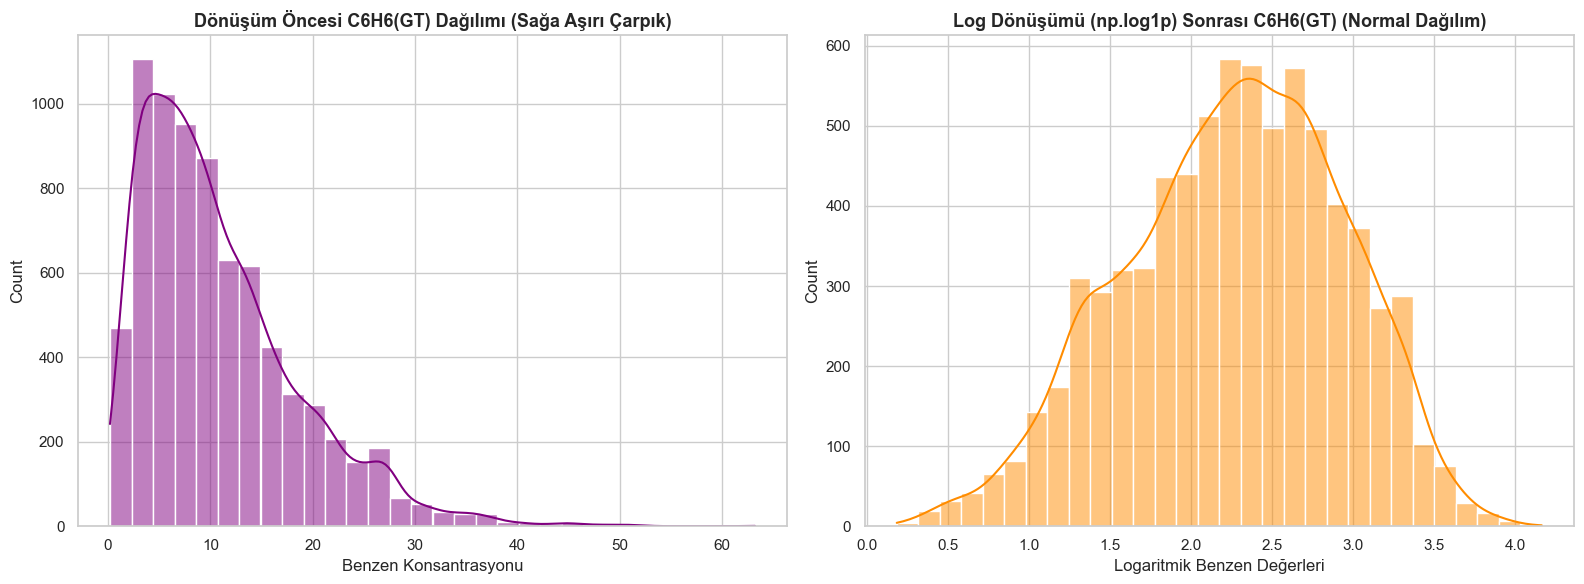


Çarpıklıklar ehlileştirildi, normalizasyon çizdirildi ve veriler sızıntısız ölçeklendi!
Ölçeklenmiş Train Matrisi Şekli: (7485, 11)


In [33]:
print("--- 1. BAĞIMSIZ DEĞİŞKENLERİN ÇARPIKLIK (SKEWNESS) SKORLARI ---")
# İdeal bir dağılımda çarpıklık skorunun -1 ile +1 arasında olması beklenir.
# +1'den büyük değerler sağa aşırı çarpıklığı (Log-Normal dağılımı) gösterir.
skew_scores = X_train.skew()
print(skew_scores.sort_values(ascending=False))


# --- 2. ÇARPIKLIK ANALİZİ & LOG DÖNÜŞÜMÜ (NORMALİZASYON) ---
# Hava kirliliği verilerinde Benzen (C6H6(GT)) gibi gazlar doğası gereği sağa aşırı çarpıktır.
# Modellerin kararlı öğrenmesi için bu değişkeni np.log1p ile normalleştiriyoruz.
plt.figure(figsize=(16, 6))

# Sol Grafik: Dönüşüm Öncesi Ham Dağılım
plt.subplot(1, 2, 1)
sns.histplot(X_train['C6H6(GT)'], kde=True, color='purple', bins=30)
plt.title('Dönüşüm Öncesi C6H6(GT) Dağılımı (Sağa Aşırı Çarpık)', fontsize=13, fontweight='bold')
plt.xlabel('Benzen Konsantrasyonu')

# Kritik Müdahale: Eğitim ve Test setlerine sızıntısız log dönüşümü uygulaması
X_train['C6H6(GT)'] = np.log1p(X_train['C6H6(GT)'])
X_test['C6H6(GT)'] = np.log1p(X_test['C6H6(GT)'])

# Sağ Grafik: Dönüşüm Sonrası Normal Dağılım
plt.subplot(1, 2, 2)
sns.histplot(X_train['C6H6(GT)'], kde=True, color='darkorange', bins=30)
plt.title('Log Dönüşümü (np.log1p) Sonrası C6H6(GT) (Normal Dağılım)', fontsize=13, fontweight='bold')
plt.xlabel('Logaritmik Benzen Değerleri')

plt.tight_layout()
plt.show()


# 3. ÖLÇEKLENDİRME / STANDARTLAŞTIRMA (SİZINTISIZ) 
# Scaler parametreleri sadece geçmişten (X_train) öğrenilir, geleceğe (X_test) sadece uygulanır.
scaler_geo = StandardScaler()

X_train_scaled = pd.DataFrame(scaler_geo.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler_geo.transform(X_test), columns=X_test.columns, index=X_test.index)

print("\nÇarpıklıklar ehlileştirildi, normalizasyon çizdirildi ve veriler sızıntısız ölçeklendi!")
print(f"Ölçeklenmiş Train Matrisi Şekli: {X_train_scaled.shape}")

# 4. FEATURE ENGINEERING - ANLAMLI ÖZELLİKLERİN OLUŞTURULMASI VE DEĞİŞKENLERİN DÖNÜŞTÜRÜLMESİ

In [34]:
def create_time_series_features(X_scaled_df, y_series):
    df_fe = X_scaled_df.copy()
    
    # 1. Zaman Kaynaklı Özellikler (Mevsimsellik yakalamak için)
    df_fe['Hour'] = df_fe.index.hour
    df_fe['DayOfWeek'] = df_fe.index.dayofweek
    df_fe['Month'] = df_fe.index.month
    
    # 2. Gecikme Özellikleri (Lag Features - Hedef değişkenin geçmiş değerleri)
    # 1 saat önceki kirlilik değeri
    df_fe['Target_Lag_1'] = y_series.shift(1)
    # 2 saat önceki kirlilik değeri
    df_fe['Target_Lag_2'] = y_series.shift(2)
    # 24 saat önceki (bir önceki günün aynı saati) kirlilik değeri
    df_fe['Target_Lag_24'] = y_series.shift(24)
    
    # 3. Hareketli Ortalama Özellikleri (Rolling Features)
    # Son 6 saatin ortalama kirlilik trendi
    df_fe['Target_Rolling_Mean_6'] = y_series.shift(1).rolling(window=6).mean()
    
    # Shift işlemlerinden dolayı ilk satırlarda oluşacak zorunlu NaN'ları dolduruyoruz
    df_fe = df_fe.ffill().bfill()
    
    return df_fe

# Özellik mühendisliğini train ve test setlerine sızıntısız uyguluyoruz
X_train_final = create_time_series_features(X_train_scaled, y_train)
X_test_final = create_time_series_features(X_test_scaled, y_test)

print(f"Özellik Mühendisliği Sonrası Yeni Sütunlar: {[col for col in X_train_final.columns if 'Target_' in col or col in ['Hour','Month']]}")
print(f"Final Matris Şekli: {X_train_final.shape}")

Özellik Mühendisliği Sonrası Yeni Sütunlar: ['Hour', 'Month', 'Target_Lag_1', 'Target_Lag_2', 'Target_Lag_24', 'Target_Rolling_Mean_6']
Final Matris Şekli: (7485, 18)


# 5. Modelleme

In [35]:
# MODEL SEÇİM GEREKÇELERİ 
# 1. Linear Regression: Zaman serisindeki temel trend doğrultusunu görmek için Baseline Regresör.
# 2. Random Forest Regressor: Zamansal gecikmeler (lag) arasındaki non-lineer ilişkileri yakalamak için.
# 3. Gradient Boosting Regressor: Zaman serisi ardışık hatalarını (residuals) optimize ederek en güçlü tahmini üretmek için.

ts_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

# Modellerin kronolojik train matrisi üzerinden eğitilmesi
for name, model in ts_models.items():
    model.fit(X_train_final, y_train)

print("Tüm zaman serisi makine öğrenmesi modelleri başarıyla eğitildi!")

Tüm zaman serisi makine öğrenmesi modelleri başarıyla eğitildi!


# 6. Model Evaluation & Comparison 

In [36]:
ts_results = []

for name, model in ts_models.items():
    y_pred = model.predict(X_test_final)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    ts_results.append({
        "Model": name,
        "MAE (Hata Miktarı)": mae,
        "RMSE (Cezalandırılmış Hata)": rmse,
        "R2 Score (Açıklayıcılık Oranı)": r2
    })

df_ts_results = pd.DataFrame(ts_results).sort_values(by="R2 Score (Açıklayıcılık Oranı)", ascending=False)
df_ts_results

,Model,MAE (Hata Miktarı),RMSE (Cezalandırılmış Hata),R2 Score (Açıklayıcılık Oranı)
0,Linear Regression,0.335204,0.484794,0.875881
1,Random Forest Regressor,0.317311,0.494384,0.870922
2,Gradient Boosting Regressor,0.360175,0.521179,0.856552
